In [1]:
from utils import * 
from monte_carlo_utils import *
from plot_utils import *

In [27]:
# Create the environment

grid_size = 8
p_barrier = 0.25  # probability of a cell being a barrier
r_barrier = -10  # reward for stepping on a barrier cell
seed_val = 41

env = build_grid(grid_size, p_barrier, r_barrier, seed_val)

In [34]:
# Create the Monte Carlo predictor 
v0_val = 0

mc_solver = MonteCarloSolver(env, MonteCarloType.FIRST_VISIT, v0_val)

In [29]:
# Create an equiprobable policy
pi_equiprob = get_equiprobable_policy(env.n)

In [39]:
# Evaluate the equiprobable policy using the Monte Carlo predictor
num_episodes = 2000
max_steps_per_episode = 1000
gamma = 0.9  # discount factor
epsilon = 0.05  # exploration rate for epsilon-soft policy improvement

mc_solver.solve(pi_equiprob, num_episodes, max_steps_per_episode, gamma=gamma, epsilon=epsilon)

In [40]:
# Get the value function for the equiprobable policy
value_func_equiprob = mc_solver.get_value_function()

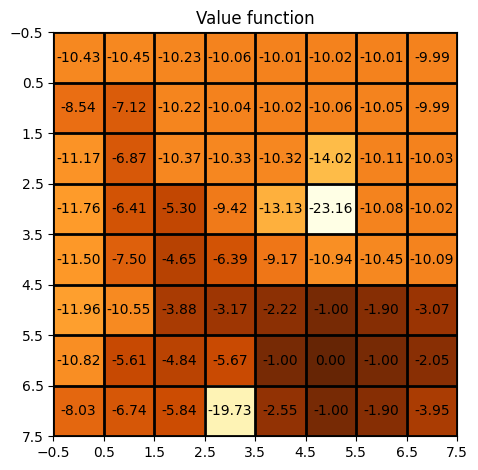

In [41]:
# Plot the value function
plot_v_values(value_func_equiprob, env.n)

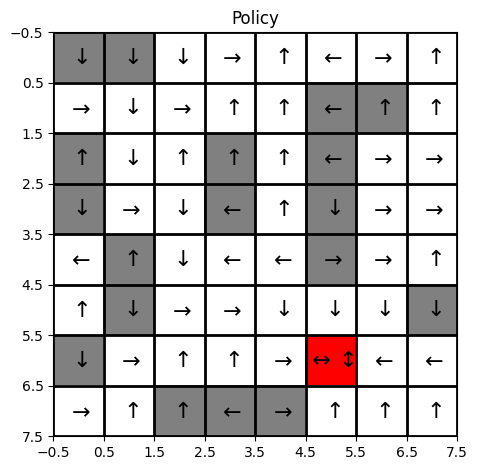

In [42]:
# Get the optimal policy from the Monte Carlo solver
optimal_policy = mc_solver.get_policy()

# Plot the optimal policy
plot_optimal_actions(env, optimal_policy)